In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.layers import Input, LayerNormalization, MultiHeadAttention, Flatten

2026-04-29 17:55:09.183930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777485309.407527      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777485309.474553      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777485309.991117      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777485309.991180      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777485309.991183      57 computation_placer.cc:177] computation placer alr

In [4]:
df = pd.read_csv("/kaggle/input/datasets/kandij/electric-production/Electric_Production.csv")

# Convert DATE column
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)

data = df[['Value']].values

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [5]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(data_scaled, time_step)

# Train-Test Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [6]:
def build_rnn():
    model = Sequential([
        SimpleRNN(50, return_sequences=True, input_shape=(time_step, 1)),
        Dropout(0.2),
        SimpleRNN(50),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

rnn_model = build_rnn()
rnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20


2026-04-29 17:56:24.602279: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.1375 - val_loss: 0.0257
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0328 - val_loss: 0.0138
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0179 - val_loss: 0.0039
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0144 - val_loss: 0.0055
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0100 - val_loss: 0.0043
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0092 - val_loss: 0.0051
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0068 - val_loss: 0.0036
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0075 - val_loss: 0.0037
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0067 - val_loss: 0.0035
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0045 - val_loss: 0.0032
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0046 - val_loss: 0.0031
Epoch 13/20


In [7]:
def build_lstm():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(time_step, 1)),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm()
lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.1981 - val_loss: 0.0469
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0255 - val_loss: 0.0398
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0192 - val_loss: 0.0181
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0137 - val_loss: 0.0221
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0142 - val_loss: 0.0192
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0134 - val_loss: 0.0188
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0128 - val_loss: 0.0189
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0119 - val_loss: 0.0187
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0118 - val_loss: 0.0189
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0126 - val_loss: 0.0192
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0124 - val_loss: 0.0182
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0118 - val_loss: 0.0187


In [8]:
def build_gru():
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(time_step, 1)),
        Dropout(0.2),
        GRU(64),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

gru_model = build_gru()
gru_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0881 - val_loss: 0.0254
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0200 - val_loss: 0.0397
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0195 - val_loss: 0.0205
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0162 - val_loss: 0.0231
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0134 - val_loss: 0.0232
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0152 - val_loss: 0.0209
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0156 - val_loss: 0.0217
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0147 - val_loss: 0.0215
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0133 - val_loss: 0.0216
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0150 - val_loss: 0.0200
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0141 - val_loss: 0.0206
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0133 - val_loss: 0.0192


In [9]:
def build_vit():
    inputs = Input(shape=(time_step, 1))

    x = LayerNormalization()(inputs)
    x = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

vit_model = build_vit()
vit_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.2568 - val_loss: 0.4202
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2477 - val_loss: 0.4089
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2275 - val_loss: 0.3980
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2073 - val_loss: 0.3871
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2091 - val_loss: 0.3764
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2172 - val_loss: 0.3661
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1977 - val_loss: 0.3561
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1880 - val_loss: 0.3463
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1936 - val_loss: 0.3366
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1775 - val_loss: 0.3274
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1724 - val_loss: 0.3183
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1723 - val_loss: 0.3095
E

In [10]:
def evaluate(model, name):
    pred = model.predict(X_test)
    pred = scaler.inverse_transform(pred)
    y_true = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)

    print(f"{name} RMSE:", rmse)
    print(f"{name} MAE:", mae)
    
    return pred

rnn_pred = evaluate(rnn_model, "RNN")
lstm_pred = evaluate(lstm_model, "LSTM")
gru_pred = evaluate(gru_model, "GRU")
vit_pred = evaluate(vit_model, "ViT")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
RNN RMSE: 4.842350651173237
RNN MAE: 3.47083604036219
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step
LSTM RMSE: 10.155598921962428
LSTM MAE: 8.319182604082892
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7d8f29691da0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step
GRU RMSE: 9

In [11]:
def forecast(model, last_sequence, steps=120):
    forecast = []
    current = last_sequence.copy()

    for _ in range(steps):
        pred = model.predict(current.reshape(1, time_step, 1))
        forecast.append(pred[0][0])

        current = np.append(current[1:], pred, axis=0)

    return scaler.inverse_transform(np.array(forecast).reshape(-1,1))

last_seq = X_test[-1]

rnn_future = forecast(rnn_model, last_seq)
lstm_future = forecast(lstm_model, last_seq)
gru_future = forecast(gru_model, last_seq)
vit_future = forecast(vit_model, last_seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━

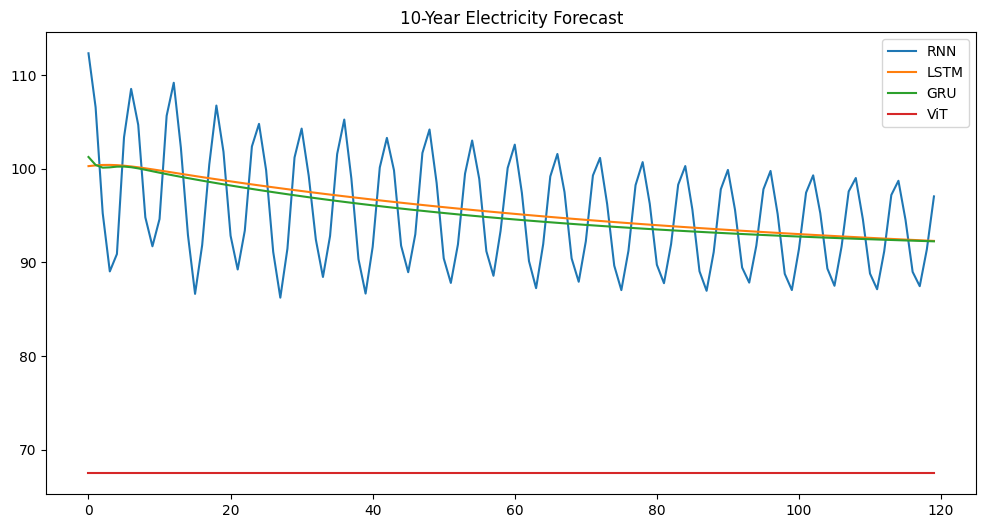

In [12]:
plt.figure(figsize=(12,6))

plt.plot(rnn_future, label="RNN")
plt.plot(lstm_future, label="LSTM")
plt.plot(gru_future, label="GRU")
plt.plot(vit_future, label="ViT")

plt.title("10-Year Electricity Forecast")
plt.legend()
plt.show()